In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import datetime as dt
from scipy.stats import pearsonr
import pickle

Matplotlib is building the font cache; this may take a moment.


In [2]:
print(f'Last run date: {dt.datetime.today()}')

Last run date: 2024-03-25 15:10:08.756681


### Functions

In [3]:
def get_multiplicative_factor(int_min, int_max, int_n_factors, df, flt_approval_rate, flt_target_ecnl):
    list_flt_factor = list(np.linspace(int_min, int_max, int_n_factors))
    list_flt_factor.append(1)
    list_flt_factor = list(dict.fromkeys(list_flt_factor))
    list_dict_row = []
    for flt_factor in tqdm(list_flt_factor):
        # create tmp df
        df_tmp = df.copy()
        # multiply factor
        df_tmp['fltDebtorScore'] = df_tmp['fltDebtorScore'] * flt_factor
        # sort
        df_tmp.sort_values(by='fltDebtorScore', ascending=True, inplace=True)
        # create row
        int_nrows = df_tmp.shape[0]
        df_tmp['row'] = list(range(1, int_nrows+1))
        df_tmp['prop_row'] = df_tmp['row'] / int_nrows
        # subset
        df_tmp = df_tmp[df_tmp['prop_row'] <= flt_approval_rate].copy()
        # mean fltDebtorScore
        flt_mean = df_tmp['fltDebtorScore'].mean()
        # row
        dict_row = {
            'flt_factor': flt_factor,
            'flt_ecnl_mean': flt_mean,
        }
        # append
        list_dict_row.append(dict_row)
    # make df
    df_tmp = pd.DataFrame(list_dict_row)
    # get diff
    df_tmp['diff'] = df_tmp['flt_ecnl_mean'] - flt_target_ecnl
    # make abs
    df_tmp['diff_abs'] = df_tmp['diff'].apply(abs)
    # sort
    df_tmp.sort_values(by='diff_abs', ascending=True, inplace=True)
    # original ecnl
    flt_original_ecnl = df_tmp[df_tmp['flt_factor'] == 1].copy()['flt_ecnl_mean'].iloc[0]
    # best factor
    flt_best_factor = df_tmp['flt_factor'].iloc[0]
    # approved ecnl
    flt_approved_ecnl = df_tmp['flt_ecnl_mean'].iloc[0]
    # return
    return flt_original_ecnl, flt_best_factor, flt_approved_ecnl, df_tmp

In [4]:
def plot_factor_analysis(flt_original_ecnl, flt_target_ecnl, flt_best_factor, flt_approved_ecnl, int_n_factors, df_tmp):
    str_title = f"""
    ECNL by Multiplicative Factor (N = {int_n_factors})
    Original ECNL = {flt_original_ecnl:0.4f}; Target ECNL = {flt_target_ecnl:0.4f}; Best Factor = {flt_best_factor:0.4f}; New ECNL = {flt_approved_ecnl:0.4}
    """
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(str_title)
    ax.set_xlabel('Factor')
    ax.set_ylabel('Mean ECNL')
    ax.plot(df_tmp['flt_factor'], df_tmp['flt_ecnl_mean'], label='ECNL')
    ax.axhline(flt_target_ecnl, linestyle='--', color='red', label=f'Target ECNL: {flt_target_ecnl:0.4f}')
    ax.axvline(flt_best_factor, linestyle='--', color='blue', label=f'Best Factor: {flt_best_factor:0.4f}')
    plt.legend()
    plt.show()

In [5]:
def make_distribution_plot(df, str_col):
    int_n = df.shape[0]
    flt_min = df[str_col].min()
    flt_max = df[str_col].max()
    flt_mean = df[str_col].mean()
    flt_sd = df[str_col].std()
    flt_mdn = df[str_col].median()
    fig, ax = plt.subplots(figsize=(9,5))
    str_title = f"""
    Distribution of {str_col} (N = {int_n})
    Min = {flt_min:0.3f}; Max = {flt_max:0.3f}; Mean = {flt_mean:0.3f} (+/- SD = {flt_sd:0.3f}); Mdn = {flt_mdn:0.3f}
    """
    ax.set_title(str_title)
    ax.set_xlabel(str_col)
    # plot
    sns.kdeplot(list(df[str_col]), ax=ax)
    # show
    plt.show()

In [6]:
def get_tier_prop_overall(dict_tier_prop_approved, flt_approval_rate):
    df_tmp = pd.DataFrame({
        'tier': dict_tier_prop_approved.keys(),
        'prop_approved': dict_tier_prop_approved.values(),
    })
    df_tmp['prop_overall'] = df_tmp['prop_approved'] * flt_approval_rate
    df_tmp['prop_overall_cumsum'] = df_tmp['prop_overall'].cumsum()
    dict_tier_prop_overall = dict(zip(df_tmp['tier'], df_tmp['prop_overall_cumsum']))
    return dict_tier_prop_overall

In [7]:
def tag_approve_decline(prop_rank, dict_tier_prop_overall):
    # tag tier
    if prop_rank <= dict_tier_prop_overall['A1']:
        return 'A1'
    elif prop_rank <= dict_tier_prop_overall['A']:
        return 'A'
    elif prop_rank <= dict_tier_prop_overall['B']:
        return 'B'
    elif prop_rank <= dict_tier_prop_overall['C']:
        return 'C'
    elif prop_rank <= dict_tier_prop_overall['D']:
        return 'D'
    else:
        return 'Decline'

### Constants

In [8]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
str_dirname_output = './output'
# clip ecnl
bool_clip_ecnl = True
# loss factor (24 to 72)
flt_factor_loss = 2.3612 # from loss forecasting
#flt_factor_loss = 1 # from loss forecasting
# multiply factor
bool_multiply_factor = True
# AD threshold
#flt_ad_threshold = 0.5
flt_ad_threshold = 0.359
# approval rate
flt_approval_rate = 0.20
# target ecnl
flt_target_ecnl = 0.20 # 20% ECNL
# tier distribution of approvals
dict_tier_prop_approved = {
    'A1': 0.0918,
    'A': 0.1115,
    'B': 0.4321,
    'C': 0.2006,
    'D': 0.1640,
}
# get sum of proportion approved tiers to make sure it adds up to 100%
flt_sum_prop_approved = np.sum(list(dict_tier_prop_approved.values()))
if flt_sum_prop_approved != 1:
    raise ValueError('Error! The sum of the approved tier proportions must equal 1.0')
else:
    pass

Project: 20231010-gen-xii


### Output directory

In [9]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Import data

In [10]:
str_filename = 'df_scores.gzip'
str_uri = f's3://{str_project}/12_dark_scoring/01_pull_scores_from_db/{str_filename}'
df = pd.read_parquet(str_uri)
df['ad_minus_pd'] = df['fltDebtor_Score_ad'] - df['fltDebtor_Score_pd']
# multiply lgd by factor
if bool_multiply_factor:
    # new ecnl
    df['fltDebtorScore'] = (df['fltDebtor_Score_pd'] * df['fltDebtor_Score_lgd']) * flt_factor_loss
else:
    pass
# clip ecnl
if bool_clip_ecnl:
    df['fltDebtorScore'] = df['fltDebtorScore'].clip(lower=0)
else:
    pass
flt_mean = df['fltDebtorScore'].mean()
print(f'Mean ECNL: {flt_mean:0.4f}')
print()
# show
df

Mean ECNL: 0.4093



,bigAccountId,dtmStampCreation,dtmApproved,dtmFunded,strScoreCardVersion,fltDebtorScore,fltDebtor_Score_lgd,fltDebtor_Score_pd,fltDebtor_Score_ad,RowNum,ad_minus_pd
0,7657064,2024-03-14 05:58:34.890,2024-03-14 05:58:54.893,NaT,genxii_v2,0.338193,0.366327,0.390988,0.054941,1,-0.336047
1,7657065,2024-03-14 06:19:01.423,NaT,NaT,genxii_v2,0.019418,0.300804,0.027340,0.085813,1,0.058473
2,7657070,2024-03-14 06:52:05.273,2024-03-14 06:52:19.663,NaT,genxii_v2,0.308928,0.389506,0.335900,0.334481,1,-0.001419
3,7657071,2024-03-14 06:56:01.100,NaT,NaT,genxii_v2,0.326382,0.418457,0.330326,0.445710,1,0.115384
4,7657072,2024-03-14 06:57:17.540,NaT,NaT,genxii_v2,0.739976,0.584907,0.535794,0.407639,1,-0.128155
...,...,...,...,...,...,...,...,...,...,...,...
17714,7704331,2024-03-24 20:13:01.587,NaT,NaT,genxii_v2,0.349018,0.485824,0.304254,0.215153,1,-0.089101
17715,7704333,2024-03-24 20:47:55.387,2024-03-24 20:48:17.837,NaT,genxii_v2,0.157911,0.448009,0.149277,0.261241,1,0.111964
17716,7704334,2024-03-24 20:51:22.957,NaT,NaT,genxii_v2,0.430783,0.450335,0.405126,0.383911,1,-0.021215
17717,7704336,2024-03-24 21:06:41.647,2024-03-24 21:07:09.940,NaT,genxii_v2,0.103666,0.392720,0.111795,0.196025,1,0.084230


### Get factor to get approved loans to hit goal ECNL

100%|██████████| 1001/1001 [00:11<00:00, 83.74it/s]


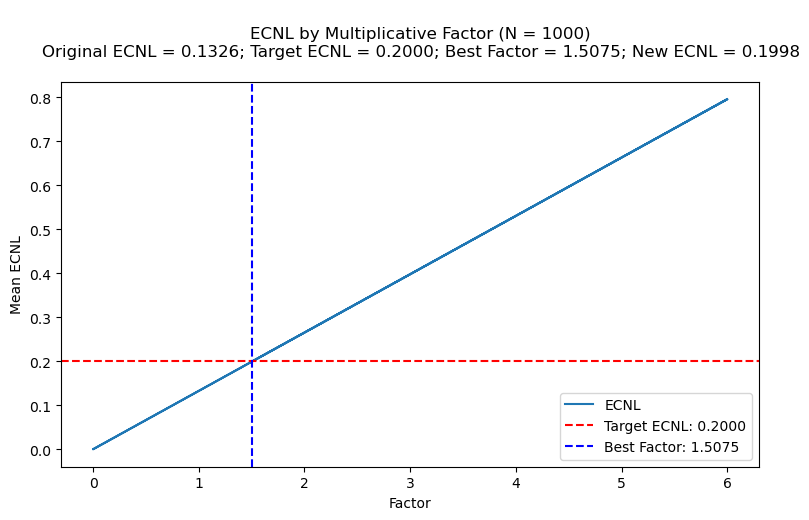

In [11]:
int_min = 0
int_max = 6
int_n_factors = 1000
# get the factor
flt_original_ecnl, flt_best_factor, flt_approved_ecnl, df_tmp = get_multiplicative_factor(
    int_min=int_min, 
    int_max=int_max, 
    int_n_factors=int_n_factors, 
    df=df, 
    flt_approval_rate=flt_approval_rate, 
    flt_target_ecnl=flt_target_ecnl,
)

# save best factor
str_filename = 'flt_best_factor.pkl'
str_local_path = f'{str_dirname_output}/{str_filename}'
pickle.dump(flt_best_factor, open(str_local_path, 'wb'))

# plot it
plot_factor_analysis(
    flt_original_ecnl=flt_original_ecnl,
    flt_target_ecnl=flt_target_ecnl, 
    flt_best_factor=flt_best_factor, 
    flt_approved_ecnl=flt_approved_ecnl, 
    int_n_factors=int_n_factors, 
    df_tmp=df_tmp,
)

### Apply factor

In [12]:
df['fltDebtorScore'] = df['fltDebtorScore'] * flt_best_factor
flt_mean = df['fltDebtorScore'].mean()
print(f'Mean ECNL: {flt_mean:0.4f}')
df

Mean ECNL: 0.6170


,bigAccountId,dtmStampCreation,dtmApproved,dtmFunded,strScoreCardVersion,fltDebtorScore,fltDebtor_Score_lgd,fltDebtor_Score_pd,fltDebtor_Score_ad,RowNum,ad_minus_pd
0,7657064,2024-03-14 05:58:34.890,2024-03-14 05:58:54.893,NaT,genxii_v2,0.509829,0.366327,0.390988,0.054941,1,-0.336047
1,7657065,2024-03-14 06:19:01.423,NaT,NaT,genxii_v2,0.029273,0.300804,0.027340,0.085813,1,0.058473
2,7657070,2024-03-14 06:52:05.273,2024-03-14 06:52:19.663,NaT,genxii_v2,0.465711,0.389506,0.335900,0.334481,1,-0.001419
3,7657071,2024-03-14 06:56:01.100,NaT,NaT,genxii_v2,0.492024,0.418457,0.330326,0.445710,1,0.115384
4,7657072,2024-03-14 06:57:17.540,NaT,NaT,genxii_v2,1.115519,0.584907,0.535794,0.407639,1,-0.128155
...,...,...,...,...,...,...,...,...,...,...,...
17714,7704331,2024-03-24 20:13:01.587,NaT,NaT,genxii_v2,0.526148,0.485824,0.304254,0.215153,1,-0.089101
17715,7704333,2024-03-24 20:47:55.387,2024-03-24 20:48:17.837,NaT,genxii_v2,0.238052,0.448009,0.149277,0.261241,1,0.111964
17716,7704334,2024-03-24 20:51:22.957,NaT,NaT,genxii_v2,0.649409,0.450335,0.405126,0.383911,1,-0.021215
17717,7704336,2024-03-24 21:06:41.647,2024-03-24 21:07:09.940,NaT,genxii_v2,0.156278,0.392720,0.111795,0.196025,1,0.084230


### Relationship between AD and PD

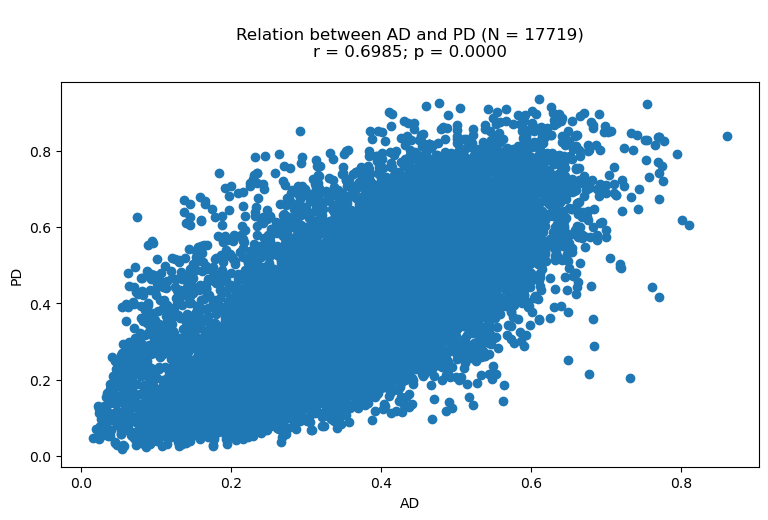

In [13]:
int_nrows = df.shape[0]
x = df['fltDebtor_Score_ad']
y = df['fltDebtor_Score_pd']
flt_coef, flt_p = pearsonr(x, y)
str_title = f"""
Relation between AD and PD (N = {int_nrows})
r = {flt_coef:0.4f}; p = {flt_p:0.4f}
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('AD')
ax.set_ylabel('PD')
ax.scatter(x, y)
plt.show()

### Tag declines from AD model

In [14]:
df['decline_ad'] = df['fltDebtorScore'].apply(
    lambda x: 1 if x >= flt_ad_threshold else 0,
)
flt_mean = df['decline_ad'].mean()
print(f'Proportion of accounts declined from AD model: {flt_mean:0.4f}')
df

Proportion of accounts declined from AD model: 0.7446


,bigAccountId,dtmStampCreation,dtmApproved,dtmFunded,strScoreCardVersion,fltDebtorScore,fltDebtor_Score_lgd,fltDebtor_Score_pd,fltDebtor_Score_ad,RowNum,ad_minus_pd,decline_ad
0,7657064,2024-03-14 05:58:34.890,2024-03-14 05:58:54.893,NaT,genxii_v2,0.509829,0.366327,0.390988,0.054941,1,-0.336047,1
1,7657065,2024-03-14 06:19:01.423,NaT,NaT,genxii_v2,0.029273,0.300804,0.027340,0.085813,1,0.058473,0
2,7657070,2024-03-14 06:52:05.273,2024-03-14 06:52:19.663,NaT,genxii_v2,0.465711,0.389506,0.335900,0.334481,1,-0.001419,1
3,7657071,2024-03-14 06:56:01.100,NaT,NaT,genxii_v2,0.492024,0.418457,0.330326,0.445710,1,0.115384,1
4,7657072,2024-03-14 06:57:17.540,NaT,NaT,genxii_v2,1.115519,0.584907,0.535794,0.407639,1,-0.128155,1
...,...,...,...,...,...,...,...,...,...,...,...,...
17714,7704331,2024-03-24 20:13:01.587,NaT,NaT,genxii_v2,0.526148,0.485824,0.304254,0.215153,1,-0.089101,1
17715,7704333,2024-03-24 20:47:55.387,2024-03-24 20:48:17.837,NaT,genxii_v2,0.238052,0.448009,0.149277,0.261241,1,0.111964,0
17716,7704334,2024-03-24 20:51:22.957,NaT,NaT,genxii_v2,0.649409,0.450335,0.405126,0.383911,1,-0.021215,1
17717,7704336,2024-03-24 21:06:41.647,2024-03-24 21:07:09.940,NaT,genxii_v2,0.156278,0.392720,0.111795,0.196025,1,0.084230,0


### Convert approved tier proportions to overall tier proportions

In [15]:
dict_tier_prop_overall = get_tier_prop_overall(
    dict_tier_prop_approved=dict_tier_prop_approved, 
    flt_approval_rate=flt_approval_rate,
)
dict_tier_prop_overall

{'A1': 0.01836, 'A': 0.04066, 'B': 0.12708, 'C': 0.16720000000000002, 'D': 0.2}

### Assign tiers

In [16]:
# sort ascending
df.sort_values(by='fltDebtorScore', ascending=True, inplace=True)
df['rank'] = list(range(1, df.shape[0]+1))
df['prop_rank'] = df['rank'] / df.shape[0]
df.drop('rank', axis=1, inplace=True)

# tag tier
df['tier'] = df['prop_rank'].apply(
    lambda x: tag_approve_decline(
        prop_rank=x, 
        dict_tier_prop_overall=dict_tier_prop_overall,
    ),
)

# show
df

,bigAccountId,dtmStampCreation,dtmApproved,dtmFunded,strScoreCardVersion,fltDebtorScore,fltDebtor_Score_lgd,fltDebtor_Score_pd,fltDebtor_Score_ad,RowNum,ad_minus_pd,decline_ad,prop_rank,tier
13745,7678240,2024-03-22 09:45:46.547,2024-03-22 09:46:14.787,NaT,genxii_v2,0.016431,0.147643,0.031265,0.092000,1,0.060735,0,0.000056,A1
9457,7671625,2024-03-19 15:08:43.967,2024-03-19 15:09:48.847,NaT,genxii_v2,0.016453,0.263327,0.017553,0.055491,1,0.037938,0,0.000113,A1
3280,7662175,2024-03-15 15:02:34.683,2024-03-15 15:03:15.450,NaT,genxii_v2,0.018552,0.197536,0.026384,0.131532,1,0.105148,0,0.000169,A1
14523,7679440,2024-03-22 13:46:59.213,2024-03-22 13:47:31.757,NaT,genxii_v2,0.018906,0.135032,0.039335,0.145735,1,0.106400,0,0.000226,A1
1807,7659888,2024-03-14 20:08:40.987,2024-03-14 20:09:02.293,NaT,genxii_v2,0.021277,0.228126,0.026203,0.108416,1,0.082213,0,0.000282,A1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14506,7679417,2024-03-22 13:41:57.443,NaT,NaT,genxii_v2,1.925056,0.633692,0.853440,0.598033,1,-0.255407,1,0.999774,Decline
8846,7670701,2024-03-19 11:31:06.673,NaT,NaT,genxii_v2,1.951452,0.633348,0.865612,0.602705,1,-0.262907,1,0.999831,Decline
2165,7660415,2024-03-15 09:54:58.543,NaT,NaT,genxii_v2,1.995699,0.628658,0.891843,0.665706,1,-0.226137,1,0.999887,Decline
13354,7677662,2024-03-21 18:20:13.807,NaT,NaT,genxii_v2,2.026857,0.635522,0.895984,0.638065,1,-0.257919,1,0.999944,Decline


### See how many declined AD accounts were approved in pricing models

In [17]:
df_tmp = df[df['tier'] != 'Decline'].copy()
int_sum_filtered = df_tmp['decline_ad'].sum()
print(f'There were {int_sum_filtered} accounts that were approved from pricing models but declined by AD model')

There were 0 accounts that were approved from pricing models but declined by AD model


### Get tier thresholds

In [18]:
df_tmp = df[df['tier'] != 'Decline'].groupby(by='tier', as_index=False).agg({
    'fltDebtorScore': 'max',
})
df_tmp

,tier,fltDebtorScore
0,A,0.133137
1,A1,0.088327
2,B,0.237506
3,C,0.279175
4,D,0.310410


In [19]:
# thresholds
df_tmp = df[df['tier'] != 'Decline'].groupby(by='tier', as_index=False).agg({
    'fltDebtorScore': 'max',
})

# write to csv
str_filename = 'df_tiers.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_tmp.to_csv(str_local_path, index=False)

# make dict
dict_ecnl_mod_thresh = dict(zip(df_tmp['tier'], df_tmp['fltDebtorScore']))
print('Tier thresholds:')
dict_ecnl_mod_thresh

Tier thresholds:


{'A': 0.13313689674626447,
 'A1': 0.0883267030820658,
 'B': 0.23750620003867742,
 'C': 0.2791745818869392,
 'D': 0.31041022726953715}

### Tier distributions overall

In [20]:
# tier distributions overall
flt_mean = df['fltDebtorScore'].mean()
print(f'Mean ECNL: {flt_mean:0.4f}')
ser_freq = df['tier'].value_counts(normalize=True)
df_freq = ser_freq.reset_index()
df_freq.columns = ['Tier','Proportion Overall']
df_freq

Mean ECNL: 0.6170


,Tier,Proportion Overall
0,Decline,0.800045
1,B,0.086404
2,C,0.040126
3,D,0.032790
4,A,0.022292
5,A1,0.018342


### Tier distributions of those approved by AD model

In [21]:
# tier distributions approved by AD
df_tmp = df[df['decline_ad'] == 0].copy()
flt_mean = df_tmp['fltDebtorScore'].mean()
print(f'Mean ECNL: {flt_mean:0.4f}')
ser_freq = df_tmp['tier'].value_counts(normalize=True)
df_freq = ser_freq.reset_index()
df_freq.columns = ['Tier','Proportion AD Approved']
df_freq

Mean ECNL: 0.2292


,Tier,Proportion AD Approved
0,B,0.338343
1,Decline,0.217017
2,C,0.157127
3,D,0.128398
4,A,0.087293
5,A1,0.071823


### Tier distributions of those approved by pricing models

In [22]:
# tier distributions approved by pricing
df_tmp = df[df['tier'] != 'Decline'].copy()
flt_mean = df_tmp['fltDebtorScore'].mean()
print(f'Mean ECNL: {flt_mean:0.4f}')
ser_freq = df_tmp['tier'].value_counts(normalize=True)
df_freq = ser_freq.reset_index()
df_freq.columns = ['Tier','Proportion Pricing Approved']
df_freq

Mean ECNL: 0.1998


,Tier,Proportion Pricing Approved
0,B,0.432120
1,C,0.200677
2,D,0.163985
3,A,0.111487
4,A1,0.091730


### Tier distributions of those approved by AD and pricing models

In [23]:
# tier distributions approved by AD and pricing
df_tmp = df[df['decline_ad'] == 0].copy()
df_tmp = df_tmp[df_tmp['tier'] != 'Decline'].copy()
flt_mean = df_tmp['fltDebtorScore'].mean()
print(f'Mean ECNL: {flt_mean:0.4f}')
ser_freq = df_tmp['tier'].value_counts(normalize=True)
df_freq = ser_freq.reset_index()
df_freq.columns = ['Tier','Proportion AD and Pricing Approved']
df_freq

Mean ECNL: 0.1998


,Tier,Proportion AD and Pricing Approved
0,B,0.432120
1,C,0.200677
2,D,0.163985
3,A,0.111487
4,A1,0.091730


### Distribution plots of everything

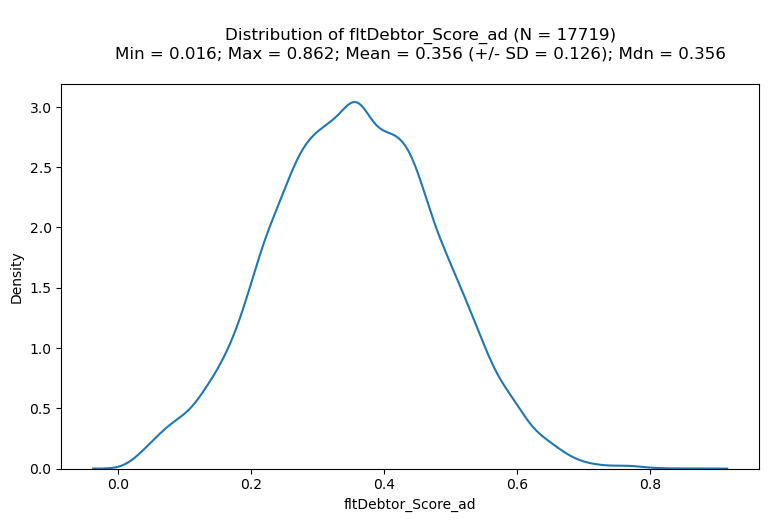

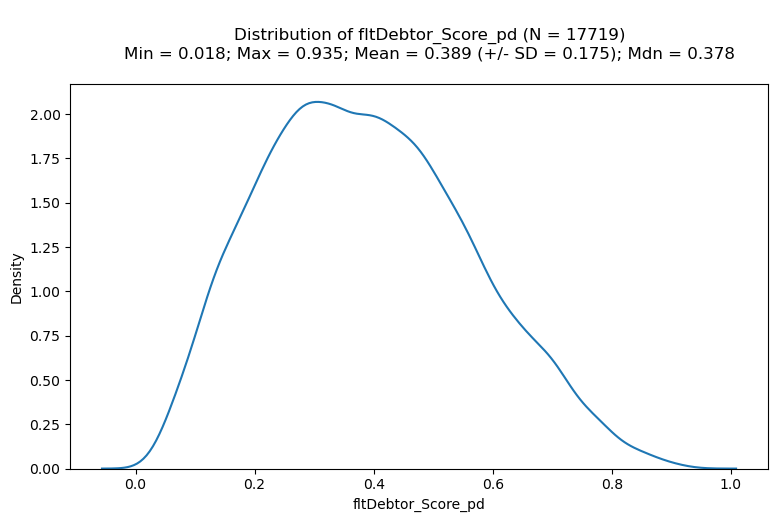

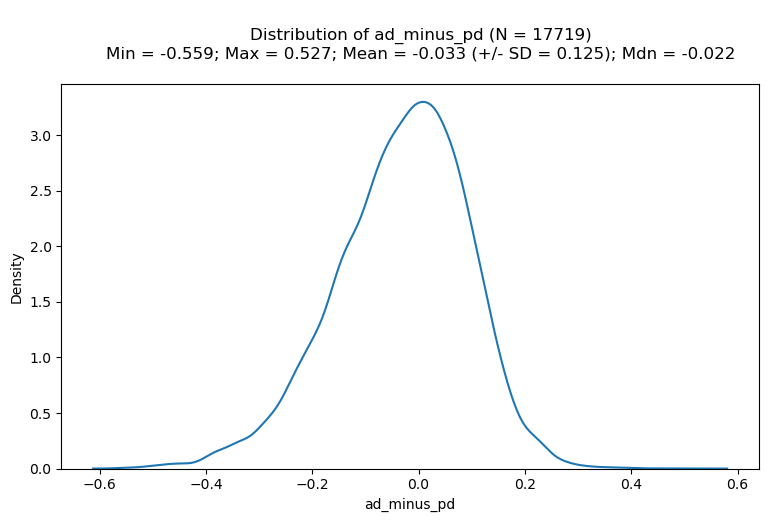

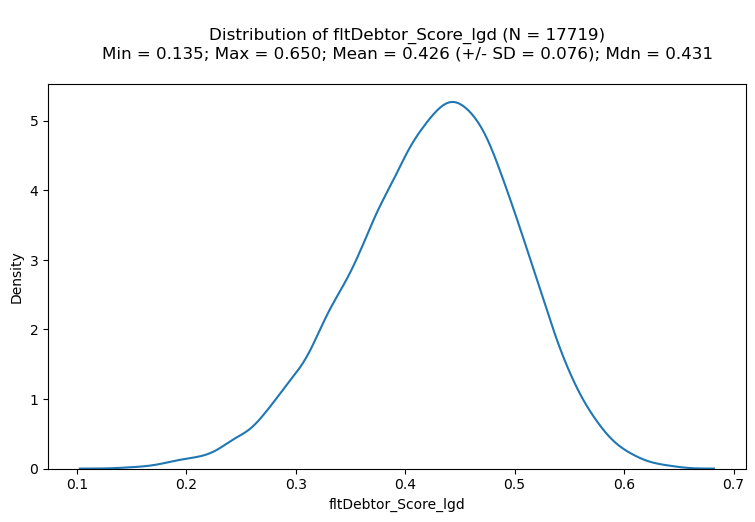

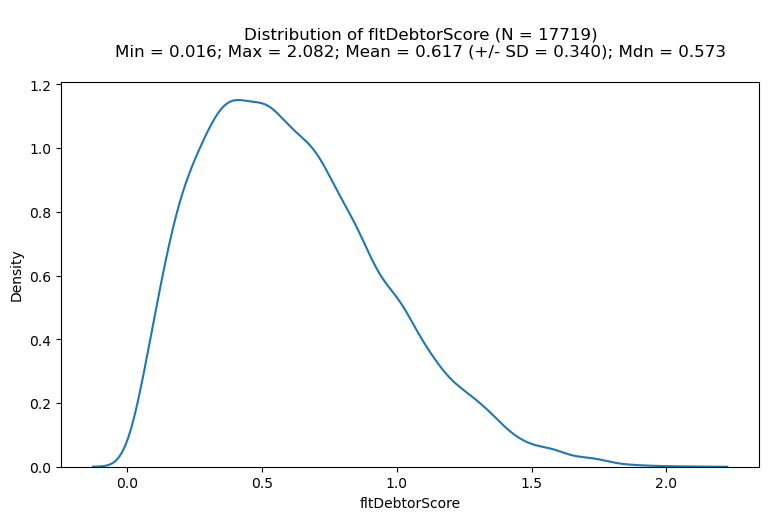

In [24]:
list_str_col = [
    'fltDebtor_Score_ad',
    'fltDebtor_Score_pd',
    'ad_minus_pd',
    'fltDebtor_Score_lgd',
    'fltDebtorScore',
]
for str_col in list_str_col:
    make_distribution_plot(
        df=df,
        str_col=str_col,
    )

### Look at AD approvals

In [25]:
df_tmp = df[df['decline_ad'] == 0].copy()
df_tmp

,bigAccountId,dtmStampCreation,dtmApproved,dtmFunded,strScoreCardVersion,fltDebtorScore,fltDebtor_Score_lgd,fltDebtor_Score_pd,fltDebtor_Score_ad,RowNum,ad_minus_pd,decline_ad,prop_rank,tier
13745,7678240,2024-03-22 09:45:46.547,2024-03-22 09:46:14.787,NaT,genxii_v2,0.016431,0.147643,0.031265,0.092000,1,0.060735,0,0.000056,A1
9457,7671625,2024-03-19 15:08:43.967,2024-03-19 15:09:48.847,NaT,genxii_v2,0.016453,0.263327,0.017553,0.055491,1,0.037938,0,0.000113,A1
3280,7662175,2024-03-15 15:02:34.683,2024-03-15 15:03:15.450,NaT,genxii_v2,0.018552,0.197536,0.026384,0.131532,1,0.105148,0,0.000169,A1
14523,7679440,2024-03-22 13:46:59.213,2024-03-22 13:47:31.757,NaT,genxii_v2,0.018906,0.135032,0.039335,0.145735,1,0.106400,0,0.000226,A1
1807,7659888,2024-03-14 20:08:40.987,2024-03-14 20:09:02.293,NaT,genxii_v2,0.021277,0.228126,0.026203,0.108416,1,0.082213,0,0.000282,A1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8089,7669551,2024-03-18 17:06:34.087,2024-03-18 17:07:12.080,NaT,genxii_v2,0.358889,0.495608,0.203437,0.401003,1,0.197566,0,0.255150,Decline
15450,7680896,2024-03-23 08:09:53.543,NaT,NaT,genxii_v2,0.358891,0.225561,0.446999,0.311864,1,-0.135135,0,0.255206,Decline
16521,7682504,2024-03-23 12:47:10.060,NaT,NaT,genxii_v2,0.358911,0.367531,0.274347,0.278616,1,0.004269,0,0.255263,Decline
11174,7674265,2024-03-20 15:10:36.437,NaT,NaT,genxii_v2,0.358946,0.310128,0.325159,0.229101,1,-0.096058,0,0.255319,Decline


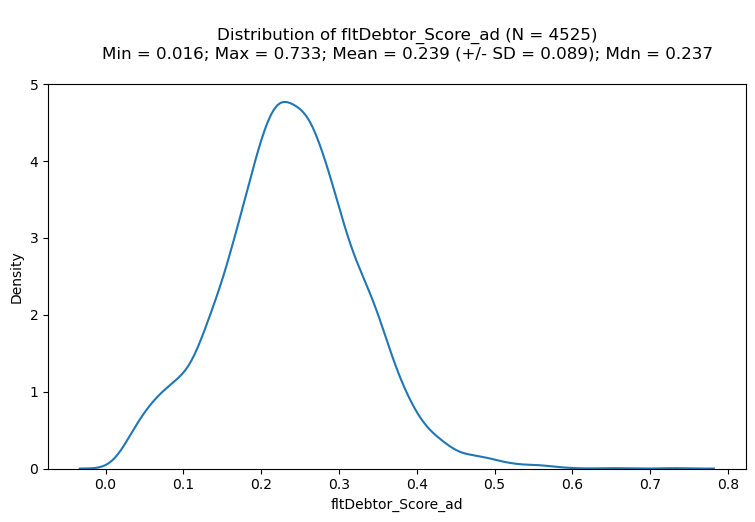

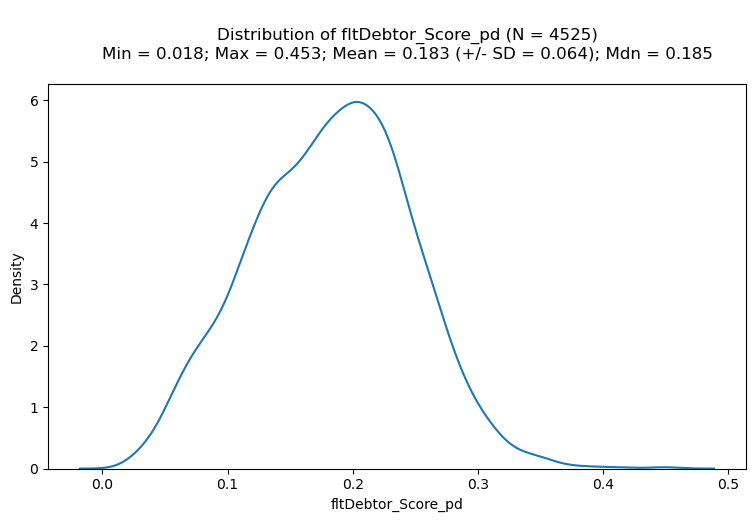

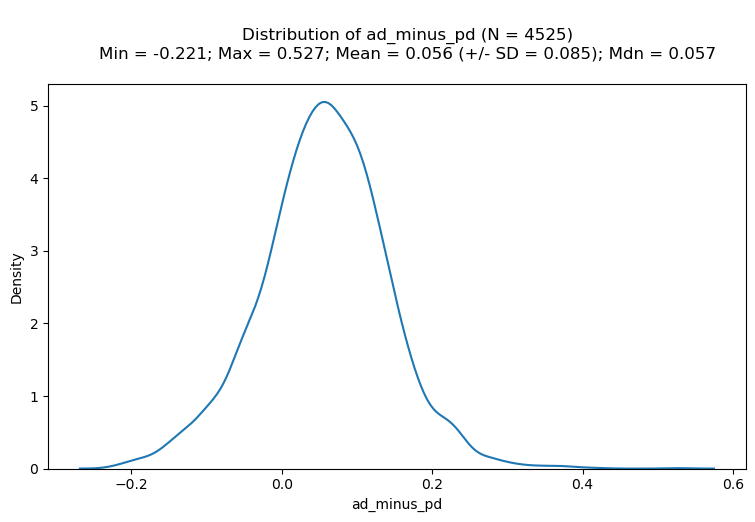

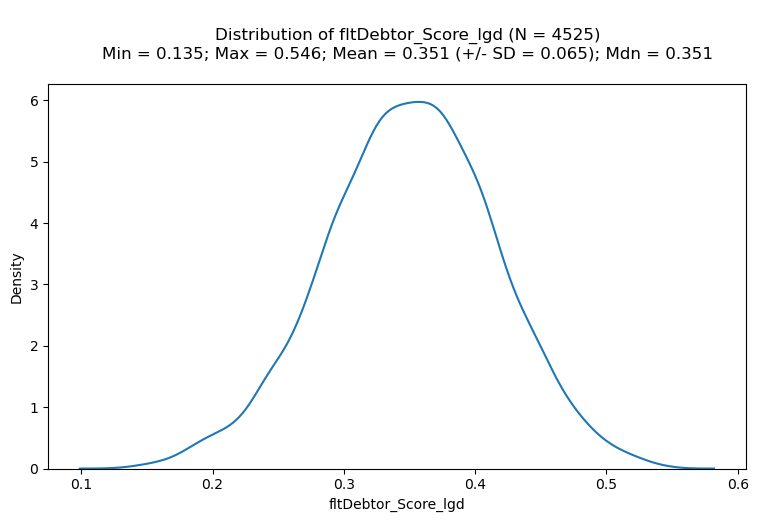

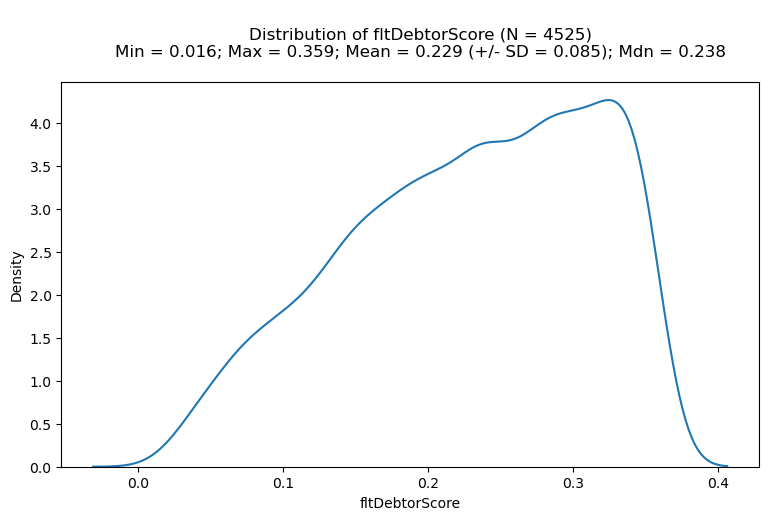

In [26]:
list_str_col = [
    'fltDebtor_Score_ad',
    'fltDebtor_Score_pd',
    'ad_minus_pd',
    'fltDebtor_Score_lgd',
    'fltDebtorScore',
]
for str_col in list_str_col:
    make_distribution_plot(
        df=df_tmp,
        str_col=str_col,
    )

### Look at approvals from pricing models

In [27]:
df_tmp = df[df['tier'] != 'Decline'].copy()
df_tmp

,bigAccountId,dtmStampCreation,dtmApproved,dtmFunded,strScoreCardVersion,fltDebtorScore,fltDebtor_Score_lgd,fltDebtor_Score_pd,fltDebtor_Score_ad,RowNum,ad_minus_pd,decline_ad,prop_rank,tier
13745,7678240,2024-03-22 09:45:46.547,2024-03-22 09:46:14.787,NaT,genxii_v2,0.016431,0.147643,0.031265,0.092000,1,0.060735,0,0.000056,A1
9457,7671625,2024-03-19 15:08:43.967,2024-03-19 15:09:48.847,NaT,genxii_v2,0.016453,0.263327,0.017553,0.055491,1,0.037938,0,0.000113,A1
3280,7662175,2024-03-15 15:02:34.683,2024-03-15 15:03:15.450,NaT,genxii_v2,0.018552,0.197536,0.026384,0.131532,1,0.105148,0,0.000169,A1
14523,7679440,2024-03-22 13:46:59.213,2024-03-22 13:47:31.757,NaT,genxii_v2,0.018906,0.135032,0.039335,0.145735,1,0.106400,0,0.000226,A1
1807,7659888,2024-03-14 20:08:40.987,2024-03-14 20:09:02.293,NaT,genxii_v2,0.021277,0.228126,0.026203,0.108416,1,0.082213,0,0.000282,A1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
818,7658362,2024-03-14 12:48:44.790,NaT,NaT,genxii_v2,0.310153,0.468461,0.185999,0.467150,1,0.281151,0,0.199729,D
511,7657871,2024-03-14 11:07:31.073,NaT,NaT,genxii_v2,0.310155,0.406328,0.214442,0.334185,1,0.119743,0,0.199786,D
14979,7680167,2024-03-22 16:07:49.190,NaT,NaT,genxii_v2,0.310177,0.276276,0.315409,0.458587,1,0.143178,0,0.199842,D
10994,7673983,2024-03-20 14:06:53.630,NaT,NaT,genxii_v2,0.310321,0.261538,0.333337,0.273434,1,-0.059903,0,0.199898,D


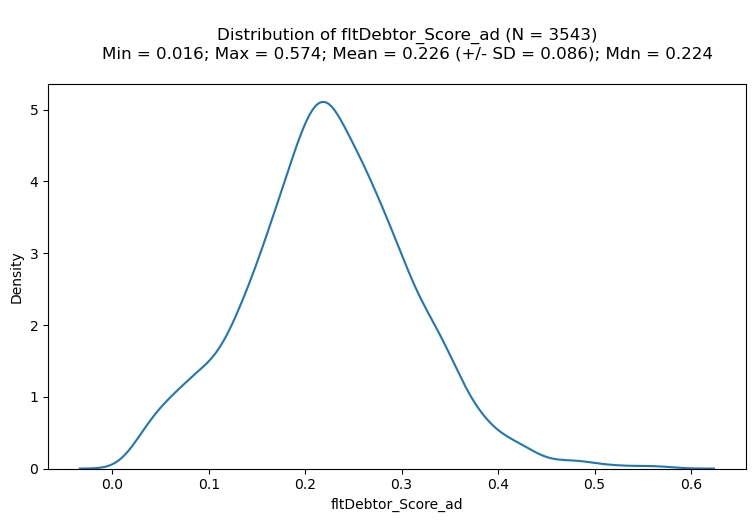

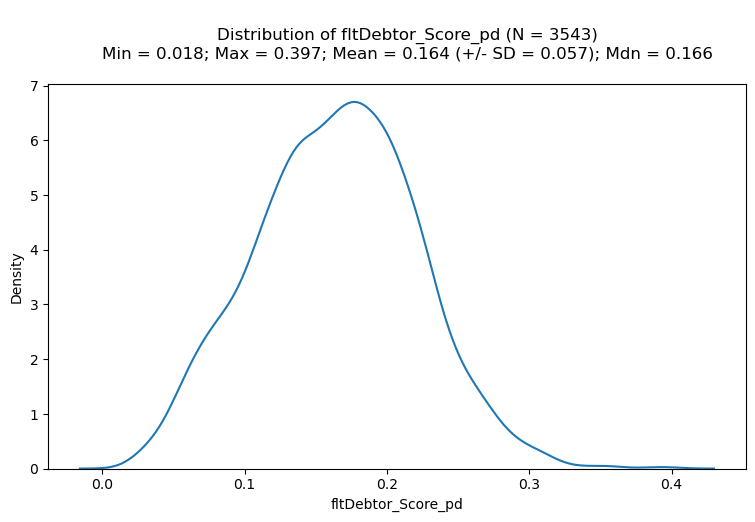

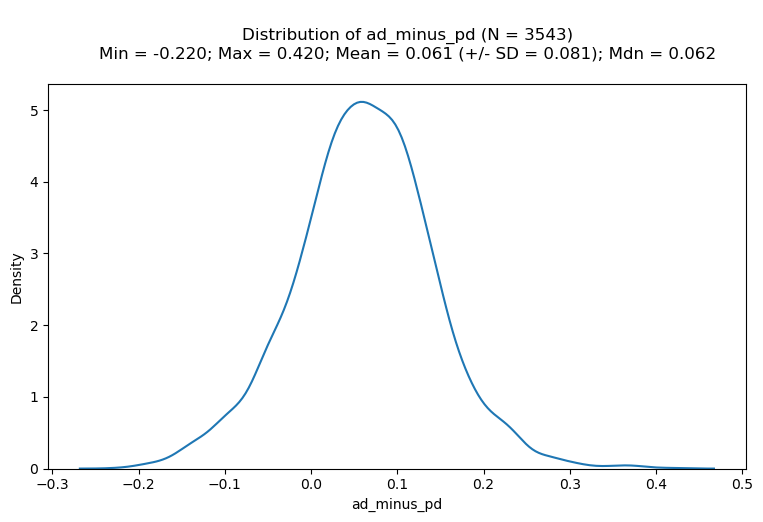

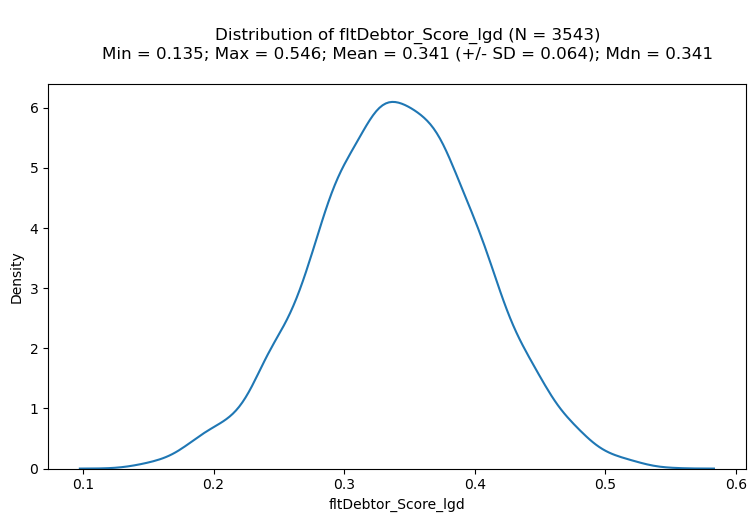

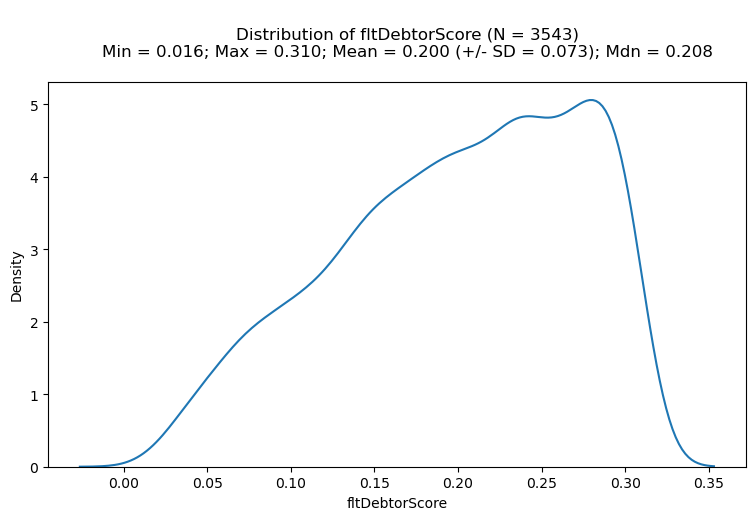

In [28]:
list_str_col = [
    'fltDebtor_Score_ad',
    'fltDebtor_Score_pd',
    'ad_minus_pd',
    'fltDebtor_Score_lgd',
    'fltDebtorScore',
]
for str_col in list_str_col:
    make_distribution_plot(
        df=df_tmp,
        str_col=str_col,
    )

### Look at approvals from the AD and pricing models

In [29]:
df_tmp = df[df['decline_ad'] == 0].copy()
df_tmp = df_tmp[df_tmp['tier'] != 'Decline'].copy()
df_tmp

,bigAccountId,dtmStampCreation,dtmApproved,dtmFunded,strScoreCardVersion,fltDebtorScore,fltDebtor_Score_lgd,fltDebtor_Score_pd,fltDebtor_Score_ad,RowNum,ad_minus_pd,decline_ad,prop_rank,tier
13745,7678240,2024-03-22 09:45:46.547,2024-03-22 09:46:14.787,NaT,genxii_v2,0.016431,0.147643,0.031265,0.092000,1,0.060735,0,0.000056,A1
9457,7671625,2024-03-19 15:08:43.967,2024-03-19 15:09:48.847,NaT,genxii_v2,0.016453,0.263327,0.017553,0.055491,1,0.037938,0,0.000113,A1
3280,7662175,2024-03-15 15:02:34.683,2024-03-15 15:03:15.450,NaT,genxii_v2,0.018552,0.197536,0.026384,0.131532,1,0.105148,0,0.000169,A1
14523,7679440,2024-03-22 13:46:59.213,2024-03-22 13:47:31.757,NaT,genxii_v2,0.018906,0.135032,0.039335,0.145735,1,0.106400,0,0.000226,A1
1807,7659888,2024-03-14 20:08:40.987,2024-03-14 20:09:02.293,NaT,genxii_v2,0.021277,0.228126,0.026203,0.108416,1,0.082213,0,0.000282,A1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
818,7658362,2024-03-14 12:48:44.790,NaT,NaT,genxii_v2,0.310153,0.468461,0.185999,0.467150,1,0.281151,0,0.199729,D
511,7657871,2024-03-14 11:07:31.073,NaT,NaT,genxii_v2,0.310155,0.406328,0.214442,0.334185,1,0.119743,0,0.199786,D
14979,7680167,2024-03-22 16:07:49.190,NaT,NaT,genxii_v2,0.310177,0.276276,0.315409,0.458587,1,0.143178,0,0.199842,D
10994,7673983,2024-03-20 14:06:53.630,NaT,NaT,genxii_v2,0.310321,0.261538,0.333337,0.273434,1,-0.059903,0,0.199898,D


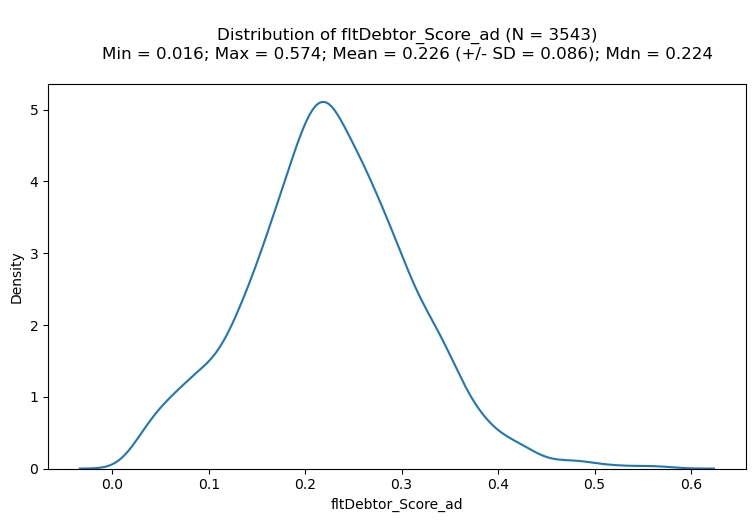

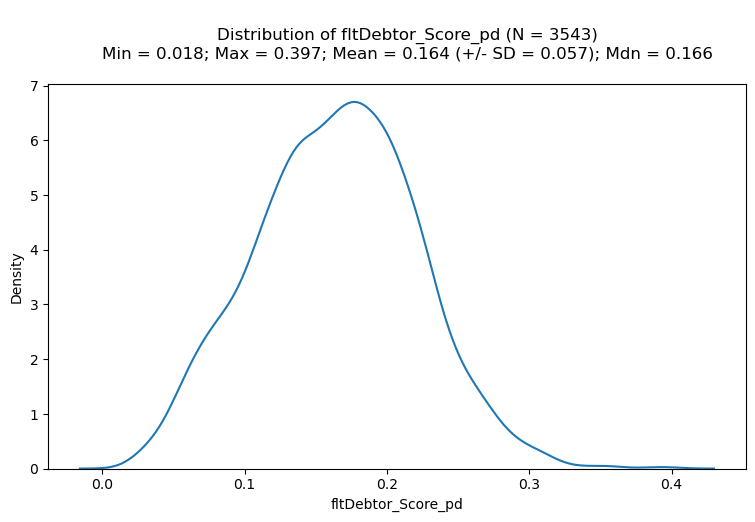

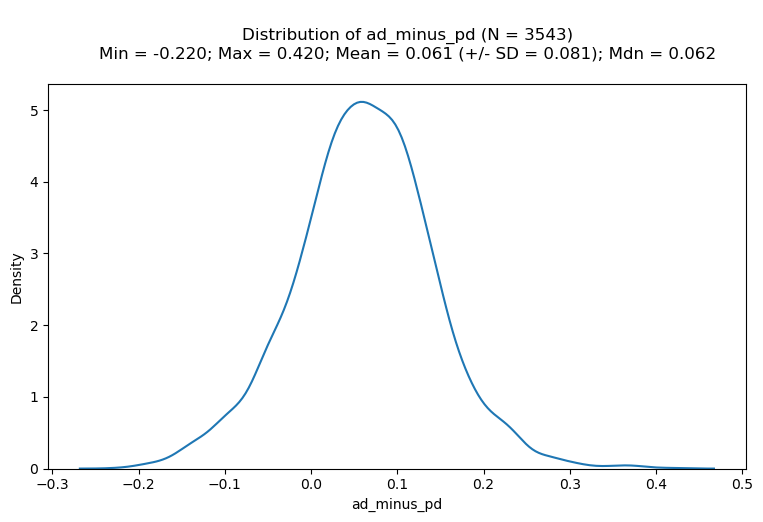

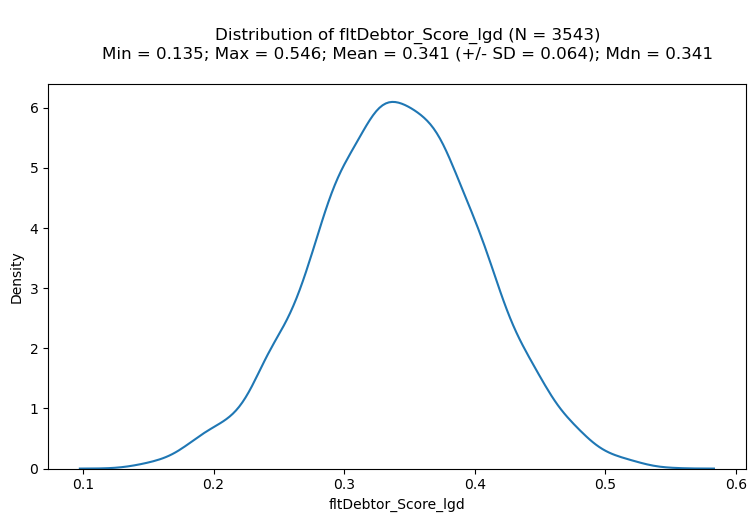

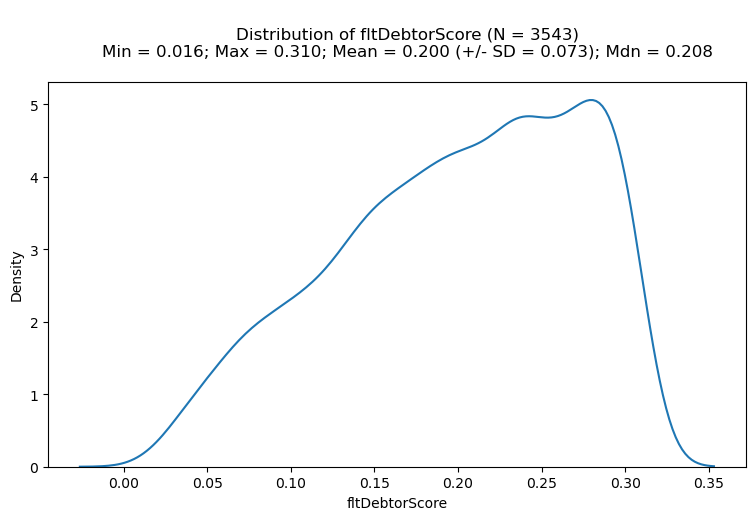

In [30]:
list_str_col = [
    'fltDebtor_Score_ad',
    'fltDebtor_Score_pd',
    'ad_minus_pd',
    'fltDebtor_Score_lgd',
    'fltDebtorScore',
]
for str_col in list_str_col:
    make_distribution_plot(
        df=df_tmp,
        str_col=str_col,
    )

### Plot

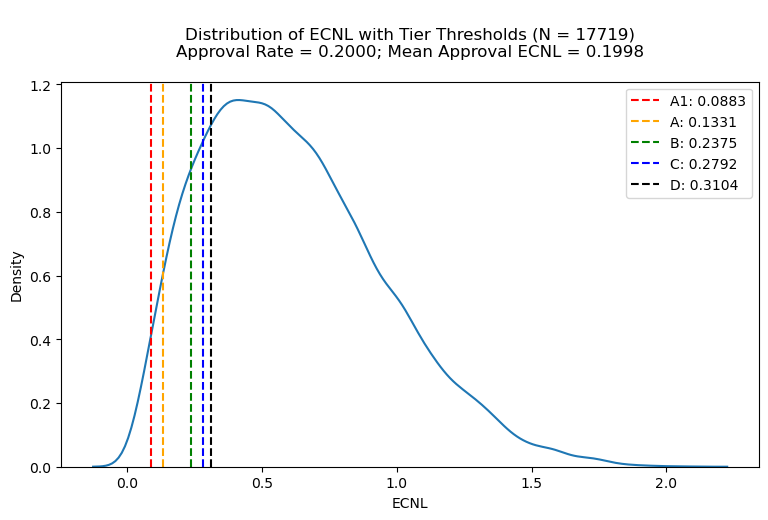

In [31]:
# get approval rate
df_tmp = df[df['tier'] != 'Decline'].copy()
flt_prop_approval = df_tmp.shape[0] / df.shape[0]
# mean ecnl of approvals
flt_mean_ecnl = df_tmp['fltDebtorScore'].mean()
# plot
list_str_tier = [
    'A1',
    'A',
    'B',
    'C',
    'D',
]
list_str_colors = [
    'red',
    'orange',
    'green',
    'blue',
    'black',
]
int_n = df.shape[0]
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Distribution of ECNL with Tier Thresholds (N = {int_n})
Approval Rate = {flt_prop_approval:0.4f}; Mean Approval ECNL = {flt_mean_ecnl:0.4f}
"""
ax.set_title(str_title)
ax.set_xlabel('ECNL')
# plot
sns.kdeplot(list(df['fltDebtorScore']), ax=ax)
# add threshold lines
for a, str_tier in enumerate(list_str_tier):
    flt_thresh = dict_ecnl_mod_thresh[str_tier]
    ax.axvline(flt_thresh, linestyle='--', color=list_str_colors[a], label=f'{str_tier}: {flt_thresh:0.4f}')
# legend
plt.legend()
# show
plt.show()